In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.load_data import load_data

In [2]:

df = load_data()

Dataset loaded successfully
Shape: (106259, 10)


In [3]:

df.shape

(106259, 10)

In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [5]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'brand'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106259 entries, 0 to 106258
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   model         106259 non-null  object 
 1   year          106259 non-null  float64
 2   price         106259 non-null  float64
 3   transmission  106259 non-null  object 
 4   mileage       106259 non-null  float64
 5   fuelType      106259 non-null  object 
 6   tax           106259 non-null  float64
 7   mpg           106259 non-null  float64
 8   engineSize    106259 non-null  float64
 9   brand         106259 non-null  object 
dtypes: float64(6), object(4)
memory usage: 8.1+ MB


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64

In [8]:
df.mean(numeric_only=True)

year           2017.072417
price         16863.144590
mileage       23220.133937
tax             123.211681
mpg              55.132858
engineSize        1.664954
dtype: float64

In [9]:
df.var(numeric_only=True)

year          4.546121e+00
price         9.565240e+07
mileage       4.463548e+08
tax           3.607438e+03
mpg           2.408369e+02
engineSize    3.115557e-01
dtype: float64

In [10]:
df.cov(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,4.546121,1.037802e+04,-3.344329e+04,22.548854,-4.124061,-0.049058
price,10378.024143,9.565240e+07,-8.836640e+07,169167.009173,-43464.421894,3456.865951
mileage,-33443.293113,-8.836640e+07,4.463548e+08,-256843.048464,57370.170662,1256.745221
tax,22.548854,1.691670e+05,-2.568430e+05,3607.437554,-413.489213,8.683678
mpg,-4.124061,-4.346442e+04,5.737017e+04,-413.489213,240.836869,-2.072416
engineSize,-0.049058,3.456866e+03,1.256745e+03,8.683678,-2.072416,0.311556


In [11]:
df.corr(numeric_only=True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.497675,-0.742418,0.176078,-0.124636,-0.041221
price,0.497675,1.000000,-0.427660,0.287984,-0.286368,0.633238
mileage,-0.742418,-0.427660,1.000000,-0.202408,0.174978,0.106571
tax,0.176078,0.287984,-0.202408,1.000000,-0.443612,0.259022
mpg,-0.124636,-0.286368,0.174978,-0.443612,1.000000,-0.239248
engineSize,-0.041221,0.633238,0.106571,0.259022,-0.239248,1.000000


In [12]:
current_year = 2026

df["car_age"] = current_year - df["year"]
df["car_age"] = df["car_age"].replace(0, 1)

df["mileage_per_year"] = df["mileage"] / df["car_age"]
df["price_per_year"] = df["price"] / df["car_age"]
df["price_per_mile"] = df["price"] / (df["mileage"] + 1)

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,brand,car_age,mileage_per_year,price_per_year,price_per_mile
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi,9.0,1748.333333,1388.888889,0.794357
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi,10.0,3620.300000,1650.000000,0.455751
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi,10.0,2994.600000,1100.000000,0.367316
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi,9.0,2883.555556,1866.666667,0.647324
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi,7.0,285.428571,2471.428571,8.654327


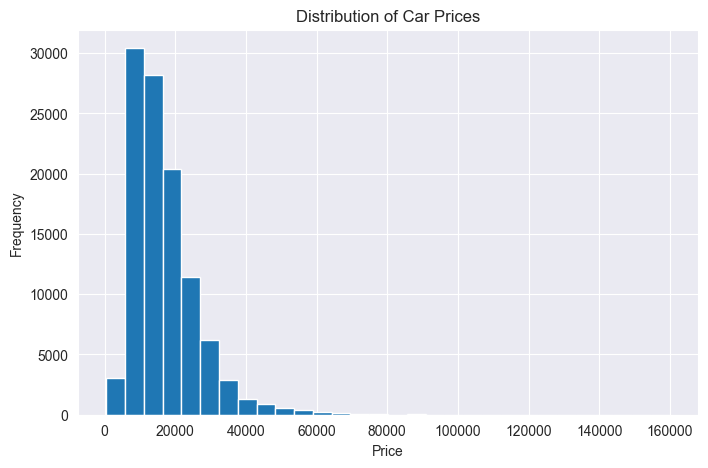

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

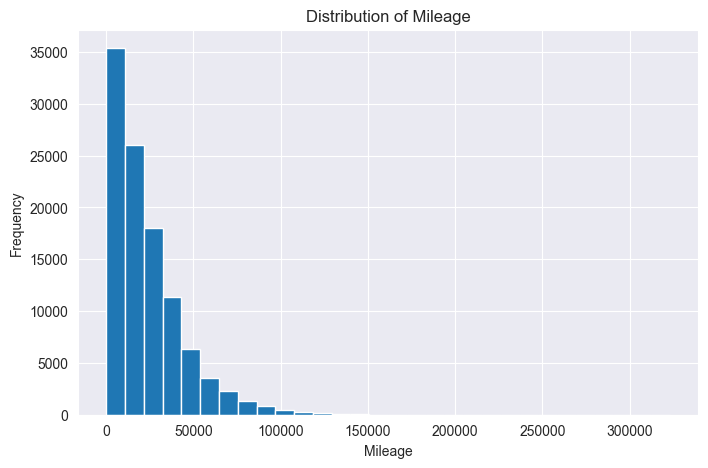

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"], bins=30)
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

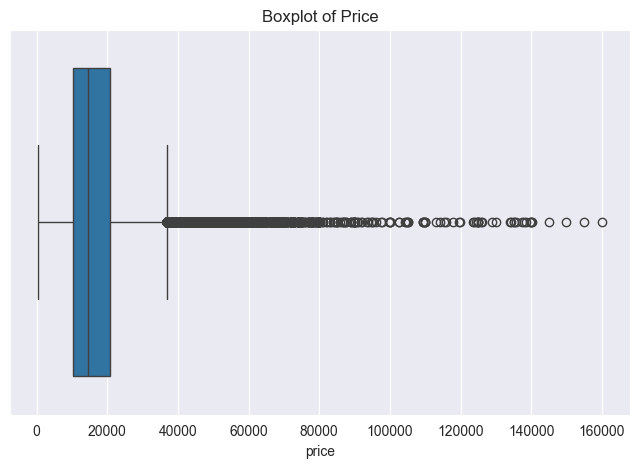

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["price"])
plt.title("Boxplot of Price")
plt.show()

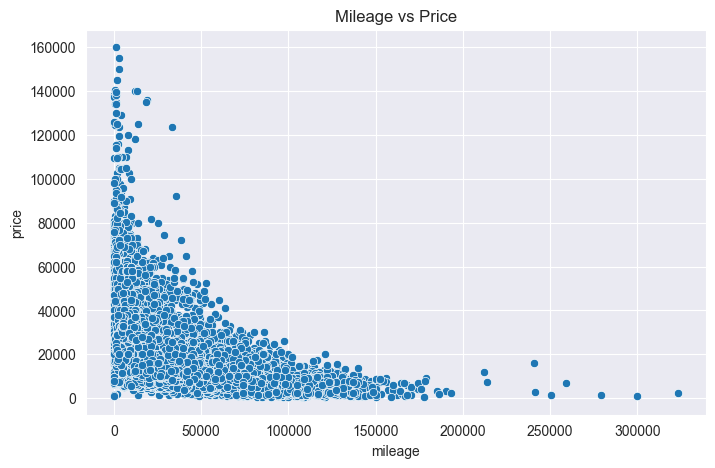

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="mileage", y="price")
plt.title("Mileage vs Price")
plt.show()

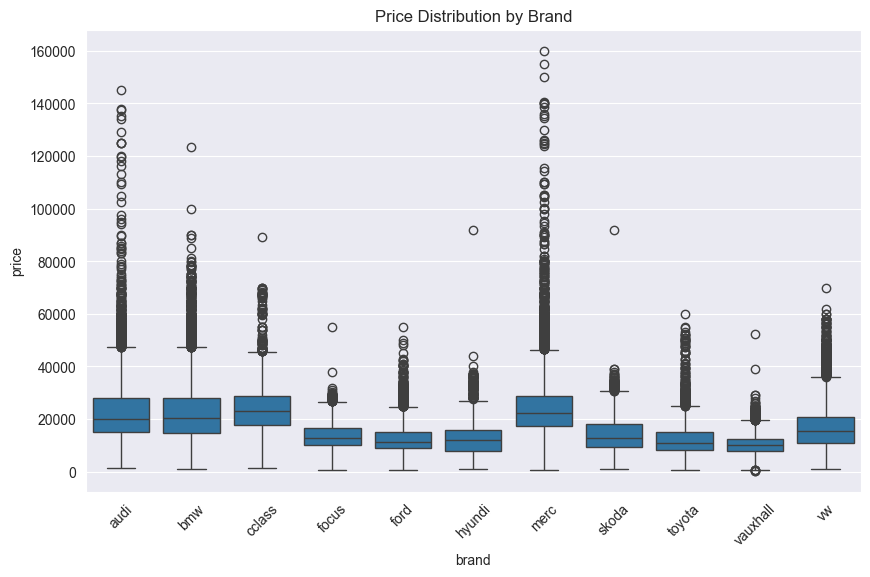

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="brand", y="price")

plt.title("Price Distribution by Brand")
plt.xticks(rotation=45)

plt.show()

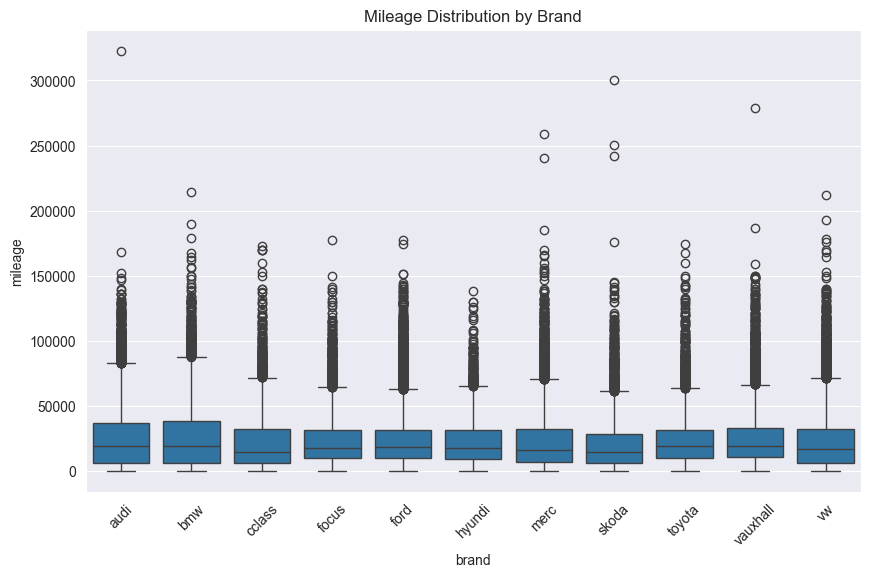

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="brand", y="mileage")

plt.title("Mileage Distribution by Brand")

plt.xticks(rotation=45)

plt.show()

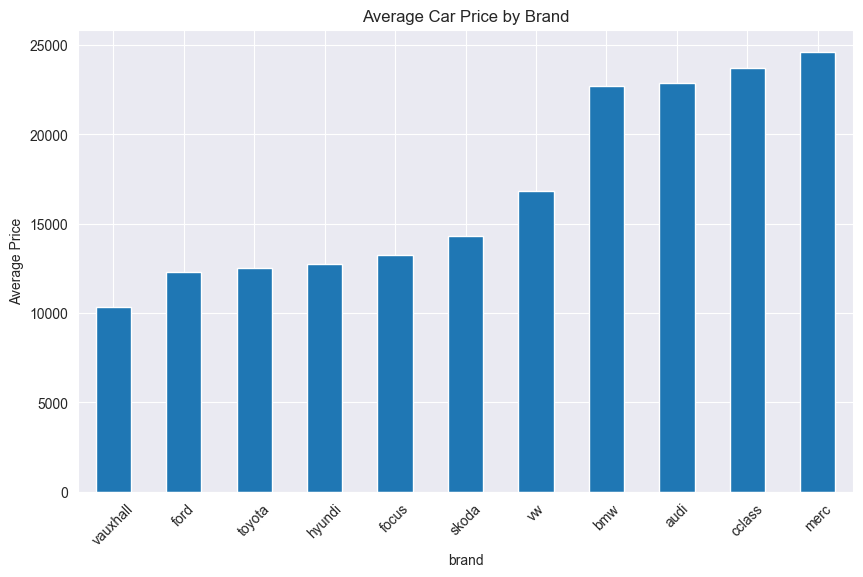

In [19]:
plt.figure(figsize=(10, 6))

df.groupby("brand")["price"].mean().sort_values().plot(kind="bar")

plt.title("Average Car Price by Brand")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

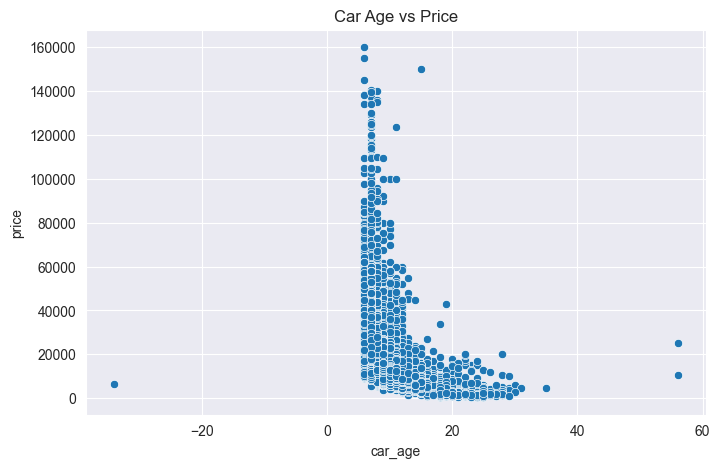

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="car_age", y="price")

plt.title("Car Age vs Price")

plt.show()

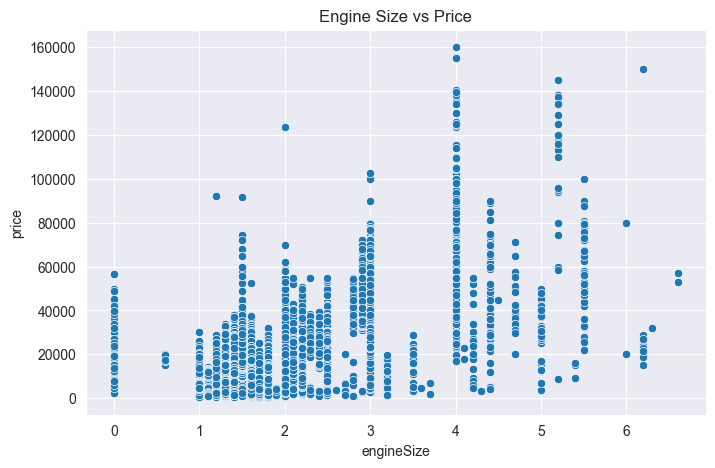

In [21]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="engineSize", y="price")

plt.title("Engine Size vs Price")

plt.show()

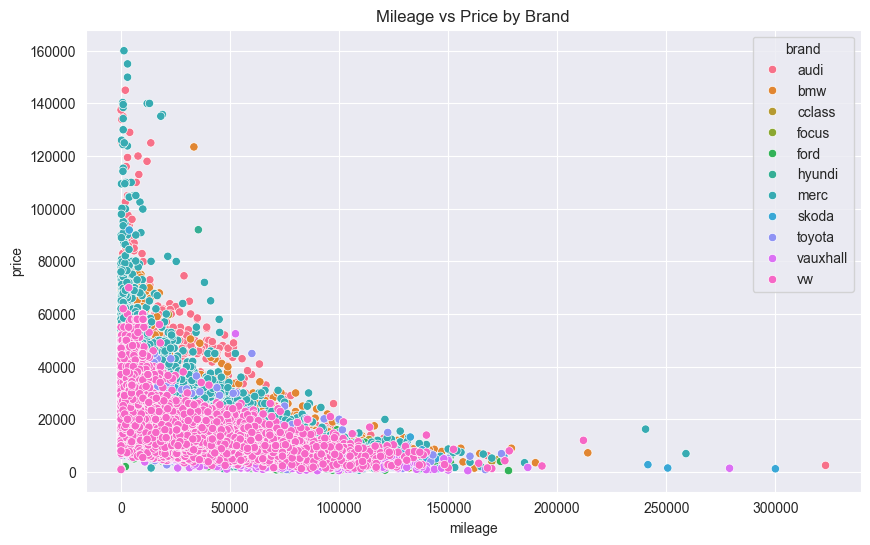

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="mileage",
    y="price",
    hue="brand"
)

plt.title("Mileage vs Price by Brand")

plt.show()

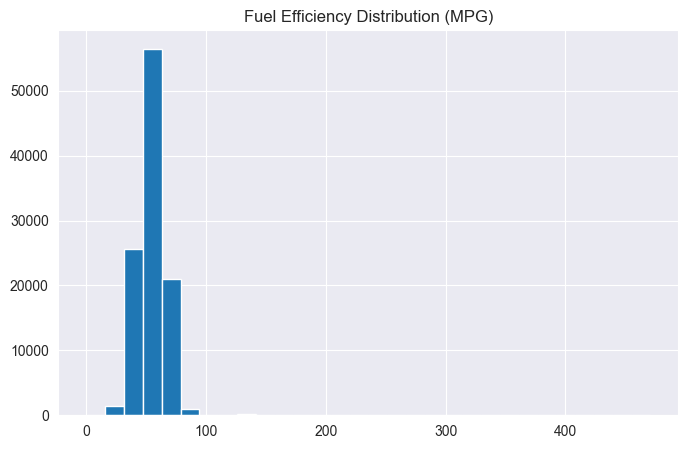

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["mpg"], bins=30)

plt.title("Fuel Efficiency Distribution (MPG)")

plt.show()

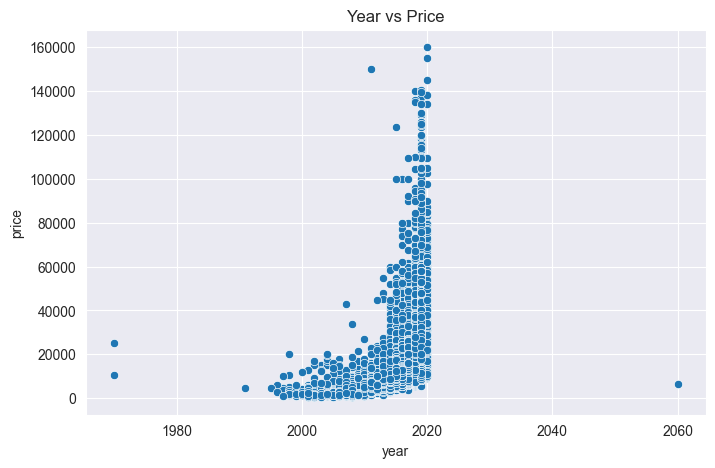

In [24]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="year", y="price")
plt.title("Year vs Price")
plt.show()

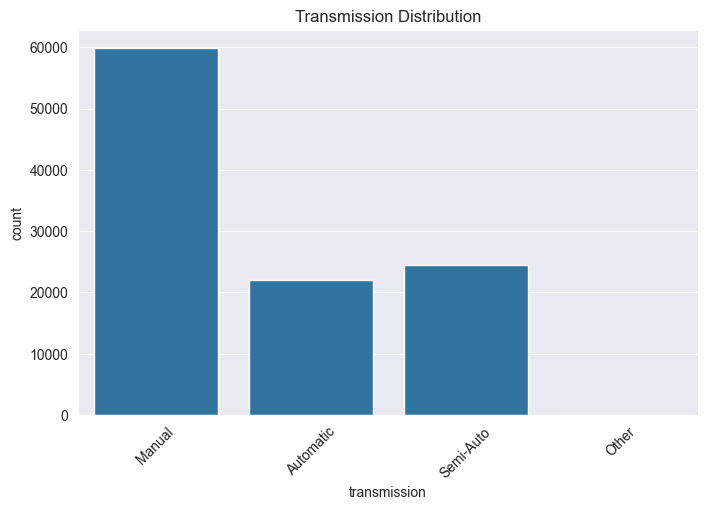

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="transmission")
plt.title("Transmission Distribution")
plt.xticks(rotation=45)
plt.show()

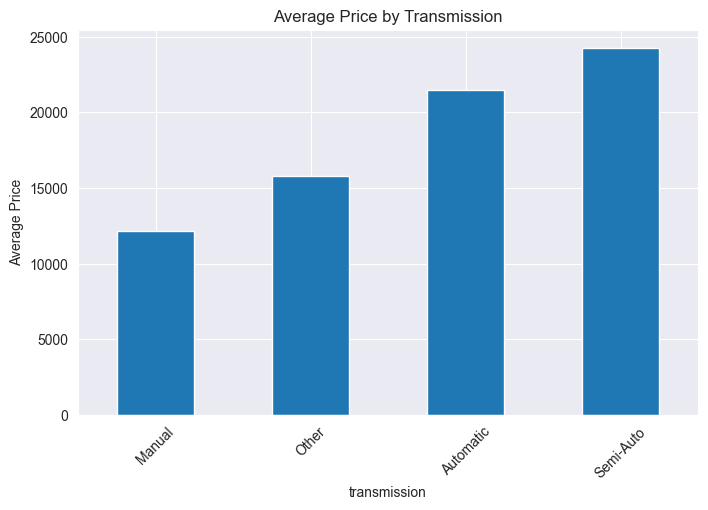

In [26]:
plt.figure(figsize=(8, 5))
df.groupby("transmission")["price"].mean().sort_values().plot(kind="bar")
plt.title("Average Price by Transmission")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

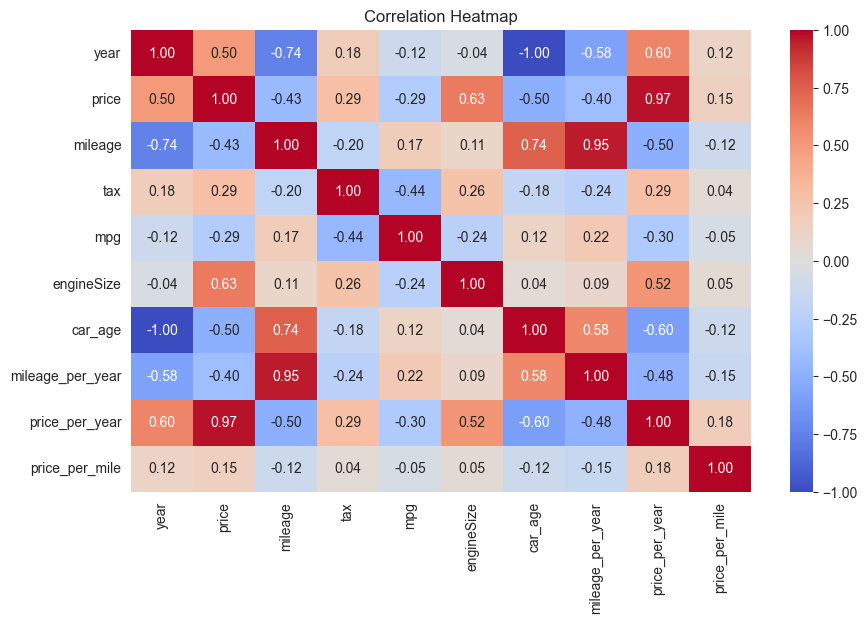

In [27]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

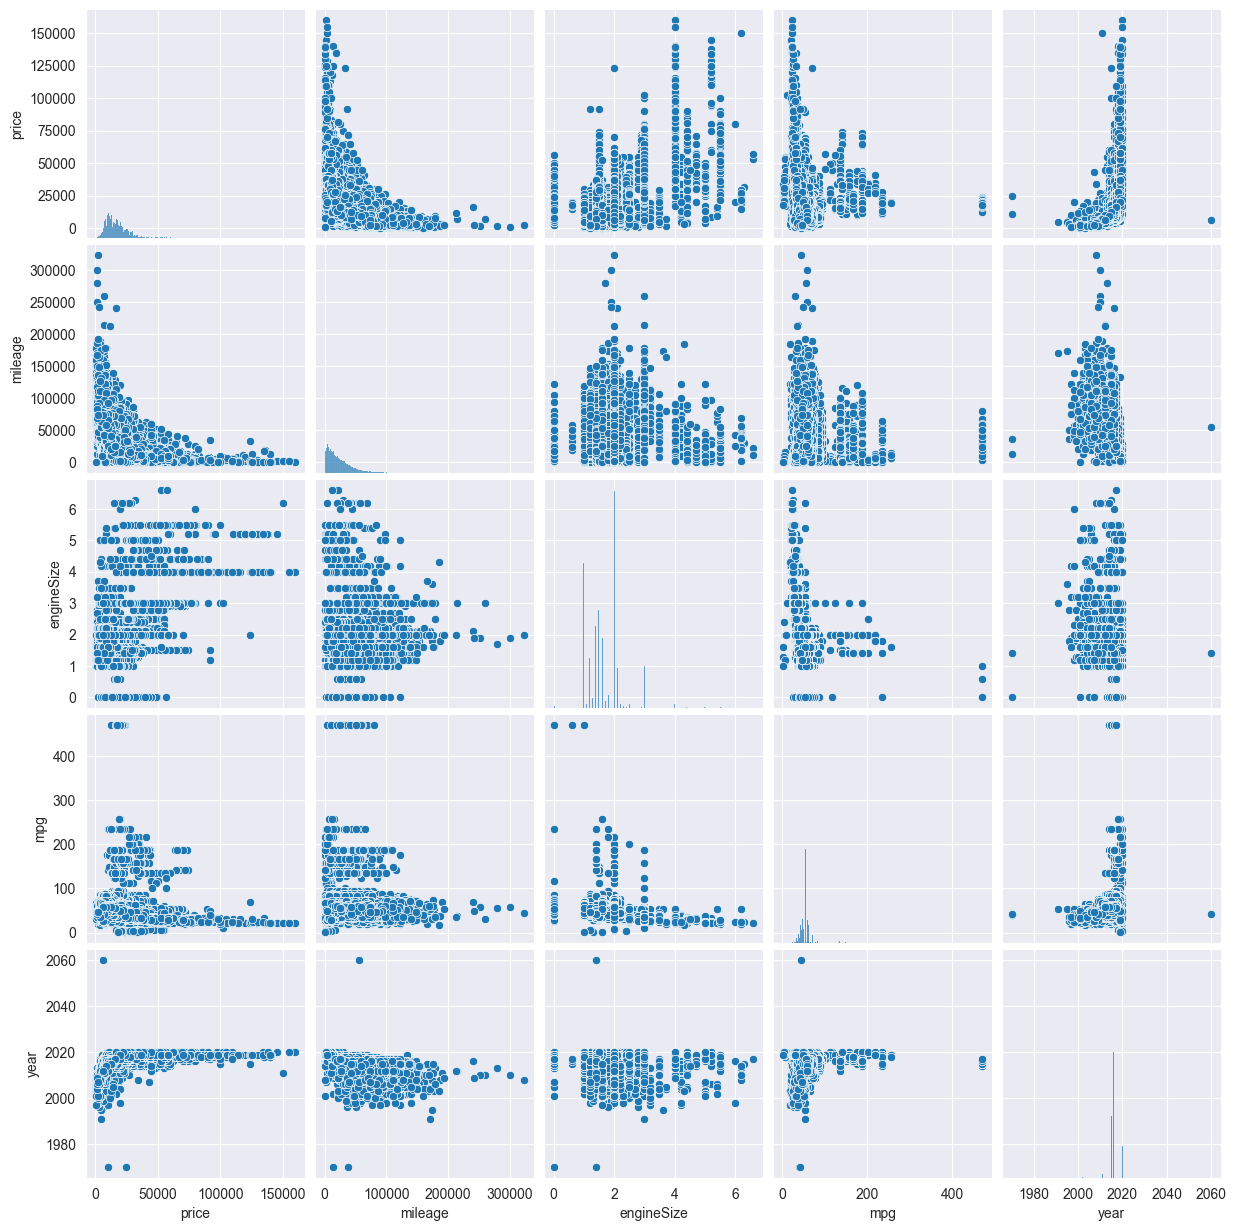

In [28]:
sns.pairplot(
    df[["price", "mileage", "engineSize", "mpg", "year"]],
    diag_kind="hist"
)

plt.show()

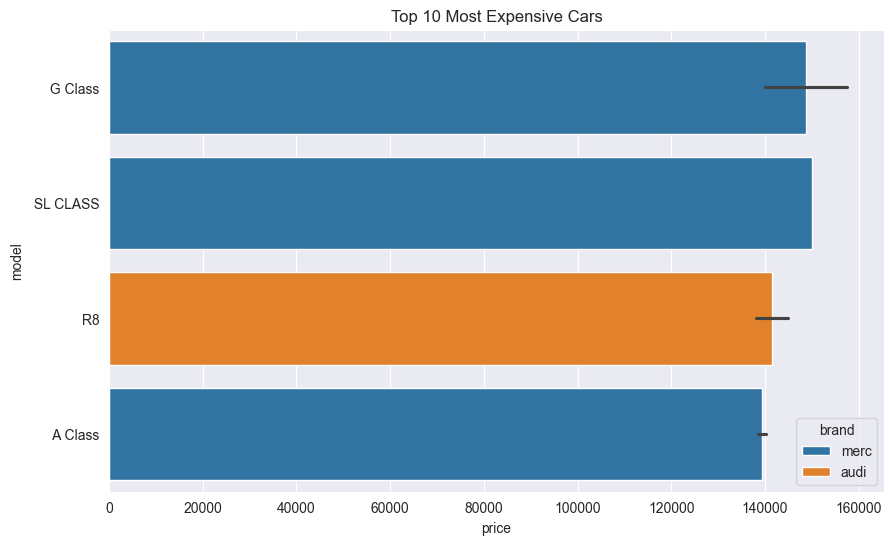

In [29]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df.select_dtypes(include=np.number).columns

scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

df_minmax.head()
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standard = pd.DataFrame(
    scaler.fit_transform(df[numeric_cols]),
    columns=numeric_cols
)

df_standard.head()
top_cars = df.sort_values("price", ascending=False).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_cars, x="price", y="model", hue="brand")

plt.title("Top 10 Most Expensive Cars")

plt.show()

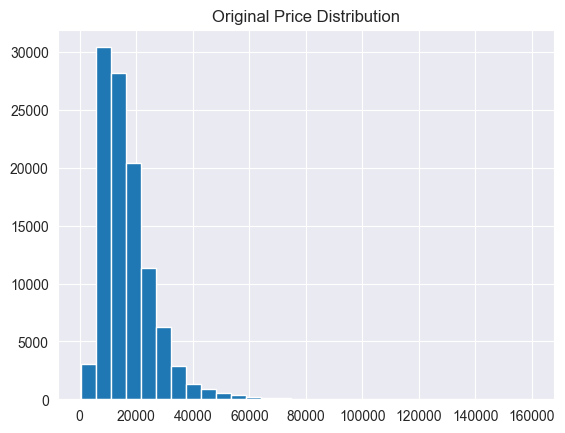

In [30]:
plt.hist(df["price"], bins=30)
plt.title("Original Price Distribution")
plt.show()

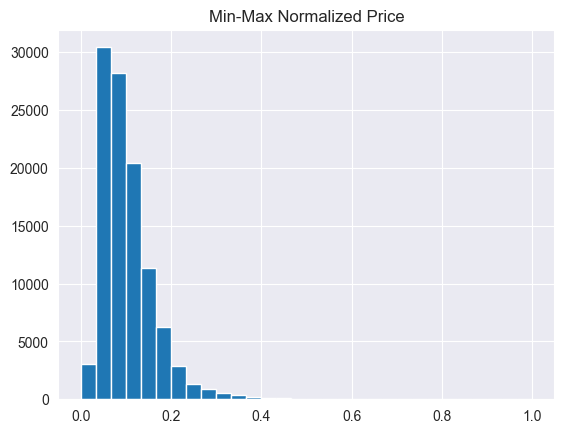

In [31]:

plt.hist(df_minmax["price"], bins=30)
plt.title("Min-Max Normalized Price")
plt.show()

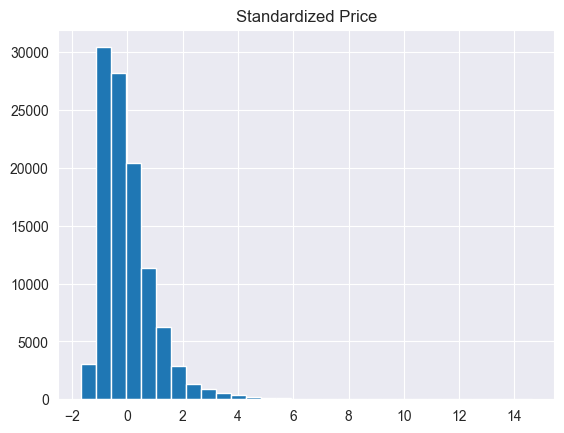

In [32]:

plt.hist(df_standard["price"], bins=30)
plt.title("Standardized Price")
plt.show()